In [118]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [119]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [120]:
def swissRoll(samples=1024, noise=0.0):
    t = 1.5 * 3.14 * (1 + 2 * torch.rand(samples, 1))
    x = t * torch.cos(t)
    y = t * torch.sin(t)
    X = torch.concat([x, y], axis=1)
    if noise > 0:
        X += noise * torch.randn(samples, 2)
    return X

In [121]:
def getCoefficients(t):
    alpha = torch.cos(torch.pi * t / 2)
    beta  = torch.sin(torch.pi * t / 2)
    return alpha, beta

In [122]:
class DiffusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 256),
            nn.LayerNorm(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.ReLU(),

            nn.Linear(256, 2)
        )

    def forward(self, x, t):
        net_input = torch.cat([x, t], dim=1)
        return self.net(net_input)

In [123]:
diffusion_model = DiffusionModel().to(device)
opt_diffusion = torch.optim.Adam(diffusion_model.parameters(), lr=1e-3)

epochs = 6000
pbar = tqdm(range(epochs), desc="Training Diffusion")

for i in pbar:
    real_data = swissRoll(1024, 0.5).to(device)

    t = torch.rand(1024, 1).to(device)

    alpha, beta = getCoefficients(t)
    noise = torch.randn_like(real_data)
    latent = alpha * real_data + beta * noise

    opt_diffusion.zero_grad()
    predicted_real_data = diffusion_model(latent, t)

    loss_diffusion = nn.functional.mse_loss(predicted_real_data, real_data)

    loss_diffusion.backward()
    opt_diffusion.step()

    if i % 400 == 0:
        print({'Loss': loss_diffusion.item()})

Training Diffusion:   0%|          | 0/6000 [00:00<?, ?it/s]

{'Loss': 48.310096740722656}
{'Loss': 6.085695266723633}
{'Loss': 6.034335136413574}
{'Loss': 5.463358402252197}
{'Loss': 5.239500045776367}
{'Loss': 5.022287845611572}
{'Loss': 5.962887763977051}
{'Loss': 5.386270523071289}
{'Loss': 5.534746170043945}
{'Loss': 5.93927526473999}
{'Loss': 4.910970211029053}
{'Loss': 5.350740909576416}
{'Loss': 6.557321548461914}
{'Loss': 5.73161506652832}
{'Loss': 6.67397403717041}


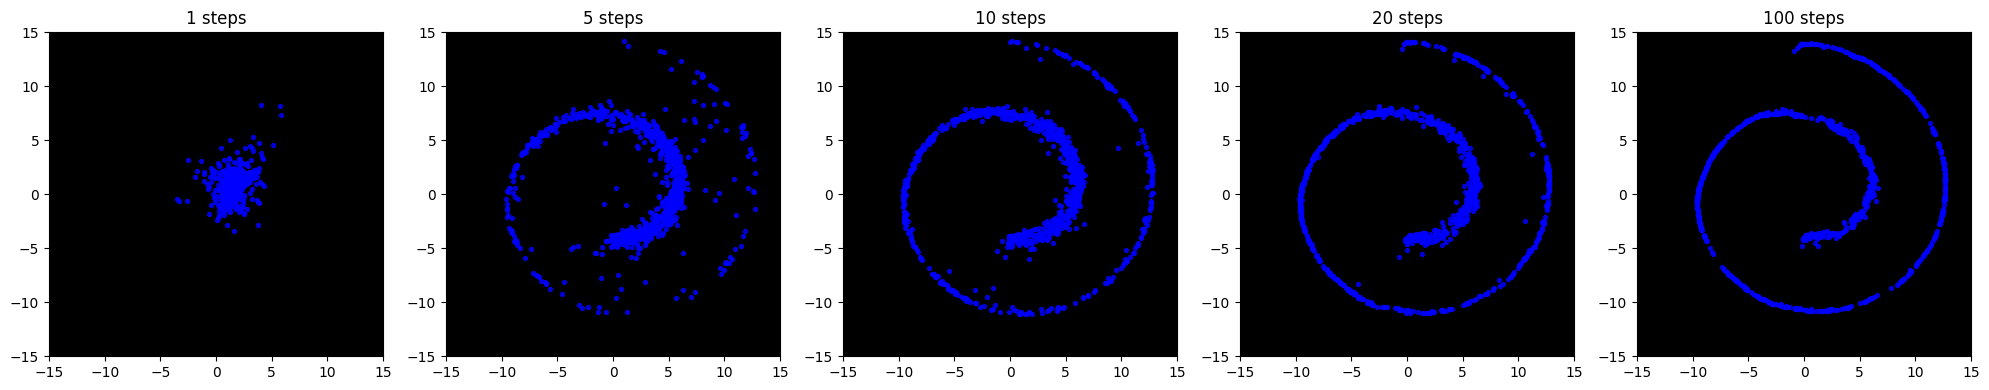

In [124]:
diffusion_model.eval()
test_samples = 1000

steps_to_plot = [1, 5, 10, 20, 100]

fig, axs = plt.subplots(1, 5, figsize=(20, 4))

for idx, num_steps in enumerate(steps_to_plot):
    with torch.no_grad():
        current_x = torch.randn(test_samples, 2).to(device)

        for step in range(num_steps, 0, -1):
            t_current = torch.full((test_samples, 1), step / num_steps).to(device)
            t_next = torch.full((test_samples, 1), (step - 1) / num_steps).to(device)

            alpha_curr, beta_curr = getCoefficients(t_current)
            alpha_next, beta_next = getCoefficients(t_next)

            pred_x0 = diffusion_model(current_x, t_current)

            pred_noise = (current_x - alpha_curr * pred_x0) / beta_curr

            current_x = alpha_next * pred_x0 + beta_next * pred_noise

        diffusion_plot_data = current_x.cpu().numpy()

    axs[idx].scatter(diffusion_plot_data[:, 0], diffusion_plot_data[:, 1], s=8, alpha=0.8, color='blue')
    axs[idx].set_title(f"{num_steps} steps")
    axs[idx].set_xlim(-15, 15)
    axs[idx].set_ylim(-15, 15)

    axs[idx].set_facecolor('#000')
    axs[idx].grid(False)

plt.tight_layout()
plt.show()